In [2]:
import sys
print(sys.executable)

/home/dbckdals/anaconda3/envs/motion_deblurring/bin/python


In [3]:
import os

base_dir = "../data/raw/kitti/images"
print("images 폴더 안:", os.listdir(base_dir))
print("train 개수:", len(os.listdir(os.path.join(base_dir, "train"))))
print("val 개수:", len(os.listdir(os.path.join(base_dir, "val"))))
print("train 앞 5개:", sorted(os.listdir(os.path.join(base_dir, "train")))[:5])

images 폴더 안: ['val', 'train']
train 개수: 5985
val 개수: 1496
train 앞 5개: ['000002.png', '000003.png', '000004.png', '000005.png', '000006.png']


image file: 000002.png
shape: (375, 1242, 3)


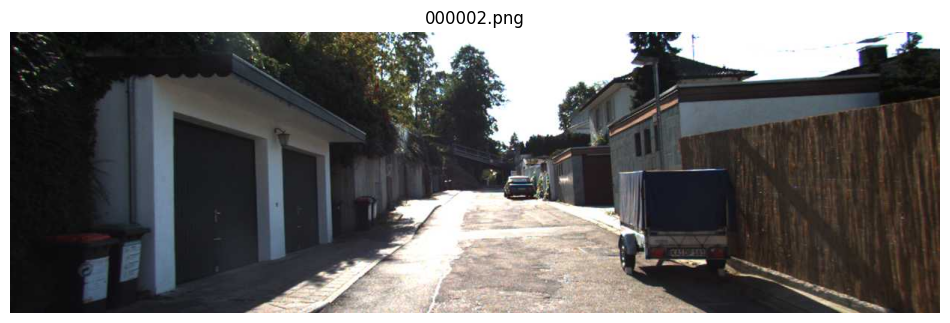

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

image_dir = "../data/raw/kitti/images/train"
image_files = sorted(os.listdir(image_dir))

img_path = os.path.join(image_dir, image_files[0])
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("image file:", image_files[0])
print("shape:", img_rgb.shape)

plt.figure(figsize=(12, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(image_files[0])
plt.show()

In [5]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
results = model.predict(source=img_path, conf=0.25, save=False, verbose=False)

print(results[0])

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

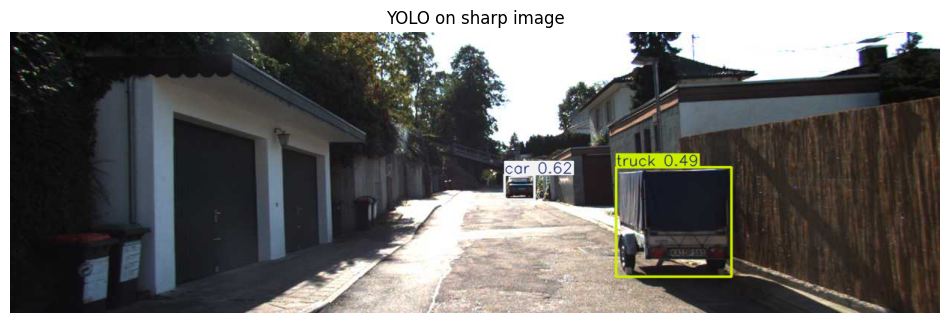

In [6]:
result_img = results[0].plot()

plt.figure(figsize=(12, 6))
plt.imshow(result_img[..., ::-1])  # BGR -> RGB
plt.axis("off")
plt.title("YOLO on sharp image")
plt.show()

In [7]:
import numpy as np

def make_motion_blur_kernel(length=9):
    kernel = np.zeros((length, length), dtype=np.float32)
    kernel[length // 2, :] = 1.0
    kernel /= kernel.sum()
    return kernel

kernel = make_motion_blur_kernel(length=9)
print(kernel)

[[          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [    0.11111     0.11111     0.11111     0.11111     0.11111     0.11111     0.11111     0.11111     0.11111]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]
 [          0           0           0           0           0           0           0           0           0]]


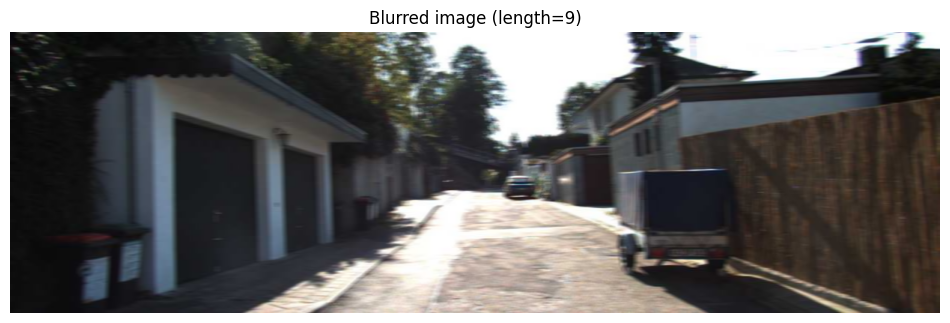

In [8]:
blurred = cv2.filter2D(img, -1, kernel)
blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(blurred_rgb)
plt.axis("off")
plt.title("Blurred image (length=9)")
plt.show()

../results/samples/temp_blurred.png
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chai

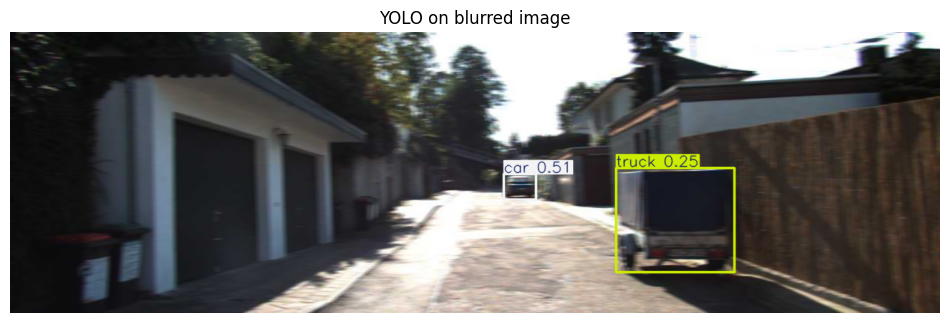

In [ ]:
temp_blur_path = "../results/samples/temp_blurred.png"
cv2.imwrite(temp_blur_path, blurred)
print(temp_blur_path)
blur_results = model.predict(source=temp_blur_path, conf=0.4, save=False, verbose=False)
print(blur_results[0])
blur_result_img = blur_results[0].plot()

plt.figure(figsize=(12, 6))
plt.imshow(blur_result_img[..., ::-1])
plt.axis("off")
plt.title("YOLO on blurred image")
plt.show()